In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ============================================
# الخلية 1: الإعداد وتحميل الخطوط والأبجدية وتحديثها من الكوربوس
# ============================================

import os
import json
import numpy as np
from pathlib import Path
import cv2
from PIL import Image, ImageDraw, ImageFont
import random
import time
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
import multiprocessing as mp
from functools import partial
import hashlib
import yaml
import shutil
import psutil

# ============================================
# إعدادات النظام والمسارات
# ============================================

# المسارات
BASE_DIR = "/content/drive/MyDrive/Old_Russian"
FONTS_DIR = os.path.join(BASE_DIR, "fonts")
ALPHABET_FILE = os.path.join(BASE_DIR, "Alphabet.json")
CORPUS_FILE = os.path.join(BASE_DIR, "corpus.txt")
MODEL_SAVE_DIR = os.path.join(BASE_DIR, "model")

# RAM Disk للتوليد
RAM_DISK = "/dev/shm"
DATASET_NAME = "Old_Russian_YOLO"
DATASET_ROOT = os.path.join(RAM_DISK, DATASET_NAME)

# إعدادات النظام
GLOBAL_SEED = 2026
NUM_CPU_CORES = mp.cpu_count()
NUM_WORKERS = min(8, NUM_CPU_CORES)  # لا نستخدم كل الـ CPU للتدريب

print("="*70)
print("🔧 إعدادات النظام")
print("="*70)
print(f"📊 عدد أنوية CPU: {NUM_CPU_CORES}")
print(f"👷 عدد Workers للتوليد: {NUM_WORKERS}")
print(f"🎲 Global Seed: {GLOBAL_SEED}")
print(f"💾 RAM Disk: {DATASET_ROOT}")

# التحقق من RAM المتاحة
ram_available = psutil.virtual_memory().available / (1024 ** 3)
print(f"📈 RAM المتاحة: {ram_available:.2f} GB")

# إنشاء المجلدات
os.makedirs(FONTS_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(DATASET_ROOT, exist_ok=True)

print(f"\n✅ تم إنشاء المجلدات:")
print(f"  📁 Drive: {BASE_DIR}")
print(f"  📁 RAM Disk: {DATASET_ROOT}")

# ============================================
# تحميل وتحديث الأبجدية واستخراج الحروف من Corpus
# ============================================

def load_and_sync_alphabet():
    """
    تحميل الأبجدية من JSON، وقراءة ملف corpus.txt لاستخراج أي حروف إضافية،
    ثم تحديث وحفظ ملف Alphabet.json بالكامل.
    """
    characters = []

    # 1. قراءة الأبجدية الموجودة في JSON أولاً
    if os.path.exists(ALPHABET_FILE):
        try:
            with open(ALPHABET_FILE, 'r', encoding='utf-8') as f:
                alphabet_data = json.load(f)

            if isinstance(alphabet_data, dict):
                if "alphabet" in alphabet_data and isinstance(alphabet_data["alphabet"], list):
                    characters = alphabet_data["alphabet"]
                elif "char_to_id" in alphabet_data:
                    characters = list(alphabet_data["char_to_id"].keys())
                else:
                    characters = list(alphabet_data.keys())
            elif isinstance(alphabet_data, list):
                characters = alphabet_data

            print(f"📄 تم تحميل {len(characters)} حرفاً أولياً من {ALPHABET_FILE}")
        except Exception as e:
            print(f"⚠️ فشلت قراءة ملف Alphabet.json: {e}")
            characters = []
    else:
        print("⚠️ ملف Alphabet.json غير موجود، سيتم إنشاؤه جديداً.")

    # 2. استخراج الحروف من ملف corpus.txt ومقارنتها
    corpus_words = []
    corpus_chars = set()

    if os.path.exists(CORPUS_FILE):
        with open(CORPUS_FILE, 'r', encoding='utf-8') as f:
            content = f.read()
            corpus_words = content.split()
            # استخراج جميع الحروف الفردية واستبعاد المسافات والسطور الجديدة
            for word in corpus_words:
                for char in word:
                    if not char.isspace():
                        corpus_chars.add(char)
        print(f"📚 تم قراءة corpus.txt: يحتوي على {len(corpus_words)} كلمة و {len(corpus_chars)} حرفاً فريداً.")
    else:
        print("⚠️ corpus.txt غير موجود، سيتم توليد كلمات عشوائية لاحقاً.")

    # 3. دمج الحروف بدون تكرار مع الحفاظ على الترتيب الأصلي
    combined_chars = list(dict.fromkeys(characters + list(corpus_chars)))

    # إذا لم نجد أي حروف في الاثنين، نلجأ إلى الأبجدية الافتراضية
    if not combined_chars:
        print("⚠️ لم يتم العثور على أي حروف، استخدام الأبجدية الافتراضية...")
        combined_chars = list("абвгдежзийклмнопрстуфхцчшщъыьэюяѣѳѵ")

    # 4. بناء القاموس الجديد لتحديث ملف Alphabet.json
    char_to_id = {char: idx for idx, char in enumerate(combined_chars)}

    updated_alphabet_data = {
        "alphabet": combined_chars,
        "char_to_id": char_to_id,
        "num_classes": len(combined_chars),
        "words_count": len(corpus_words)
    }

    # 5. حفظ التعديلات في ملف Alphabet.json
    try:
        with open(ALPHABET_FILE, 'w', encoding='utf-8') as f:
            json.dump(updated_alphabet_data, f, ensure_ascii=False, indent=2)
        print(f"💾 تم تحديث وحفظ {ALPHABET_FILE} بنجاح!")
    except Exception as e:
        print(f"⚠️ تعذر حفظ التحديثات في Alphabet.json: {e}")

    print(f"\n📊 الأبجدية النهائية المعتمة:")
    print(f"  🔤 عدد الأحرف الكلي (Classes): {len(combined_chars)}")
    print(f"  🔣 قائمة الأحرف: {' '.join(combined_chars)}")

    return combined_chars, corpus_words

characters, corpus_words = load_and_sync_alphabet()

# ============================================
# تحميل الخطوط إلى RAM مرة واحدة
# ============================================

def load_fonts_to_ram():
    """تحميل جميع الخطوط إلى RAM مرة واحدة"""

    fonts_in_ram = {}
    font_extensions = ['.ttf', '.otf', '.ttc', '.fon']

    print(f"\n📝 تحميل الخطوط إلى RAM...")

    if os.path.exists(FONTS_DIR):
        font_files = [f for f in os.listdir(FONTS_DIR)
                      if any(f.lower().endswith(ext) for ext in font_extensions)]

        for filename in tqdm(font_files, desc="تحميل الخطوط"):
            font_path = os.path.join(FONTS_DIR, filename)

            try:
                # اختبار تحميل الخط بحجم صغير
                test_font = ImageFont.truetype(font_path, 20)

                # تحميل الخط إلى RAM (نحتفظ بالمسار فقط، PIL سيحمّله عند الحاجة)
                fonts_in_ram[filename] = font_path

            except Exception as e:
                print(f"  ⚠️ فشل تحميل {filename}: {e}")

    if not fonts_in_ram:
        print("  ⚠️ لم يتم العثور على خطوط، استخدام الخط الافتراضي")
        try:
            default_font = "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"
            if os.path.exists(default_font):
                fonts_in_ram['default'] = default_font
            else:
                fonts_in_ram['default'] = None
        except:
            fonts_in_ram['default'] = None

    print(f"  ✅ تم تحميل {len(fonts_in_ram)} خط إلى RAM")
    return fonts_in_ram

fonts_dict = load_fonts_to_ram()
fonts_list = list(fonts_dict.values())

# ============================================
# تجهيز الكلمات للاستخدام في التوليد
# ============================================

def prepare_corpus_words(words):
    """تأكيد وجود كلمات أو توليد عشوائي إذا كان الكوربوس فارغاً"""
    if not words:
        print("\n⚠️ لا توجد كلمات في الكوربوس، سيتم توليد كلمات عشوائية...")
        generated_words = []
        for _ in range(1000):
            word_len = random.randint(3, 10)
            word = ''.join(random.choices(characters, k=word_len))
            generated_words.append(word)
        return list(dict.fromkeys(generated_words))

    return list(dict.fromkeys(words))

corpus_words = prepare_corpus_words(corpus_words)

# ============================================
# إعدادات التوليد
# ============================================

IMAGES_PER_CHAR = 500
IMG_WIDTH = 640
IMG_HEIGHT = 640
TOTAL_IMAGES = len(characters) * IMAGES_PER_CHAR

print(f"\n🎯 خطة التوليد:")
print(f"  📊 إجمالي الصور: {TOTAL_IMAGES:,}")
print(f"  🔤 الأحرف: {len(characters)}")
print(f"  🖼️ صور/حرف: {IMAGES_PER_CHAR}")
print(f"  ⚡ التوليد: Parallel باستخدام {NUM_WORKERS} processes")

print("\n" + "="*70)
print("✅ اكتمل الإعداد بنجاح وجاهز لمرحلة التوليد")
print("="*70)

🔧 إعدادات النظام
📊 عدد أنوية CPU: 2
👷 عدد Workers للتوليد: 2
🎲 Global Seed: 2026
💾 RAM Disk: /dev/shm/Old_Russian_YOLO
📈 RAM المتاحة: 9.14 GB

✅ تم إنشاء المجلدات:
  📁 Drive: /content/drive/MyDrive/Old_Russian
  📁 RAM Disk: /dev/shm/Old_Russian_YOLO
📄 تم تحميل 38 حرفاً أولياً من /content/drive/MyDrive/Old_Russian/Alphabet.json
⚠️ corpus.txt غير موجود، سيتم توليد كلمات عشوائية لاحقاً.
💾 تم تحديث وحفظ /content/drive/MyDrive/Old_Russian/Alphabet.json بنجاح!

📊 الأبجدية النهائية المعتمة:
  🔤 عدد الأحرف الكلي (Classes): 38
  🔣 قائمة الأحرف: п к щ н м х е э б р ь и з г ш ц ч ѳ ѣ ѵ ю л в ф с т о ы а у й я д ж ъ ѧ Ѥ Ѿ

📝 تحميل الخطوط إلى RAM...


تحميل الخطوط: 100%|██████████| 17/17 [00:00<00:00, 163.40it/s]

  ✅ تم تحميل 17 خط إلى RAM

⚠️ لا توجد كلمات في الكوربوس، سيتم توليد كلمات عشوائية...

🎯 خطة التوليد:
  📊 إجمالي الصور: 19,000
  🔤 الأحرف: 38
  🖼️ صور/حرف: 500
  ⚡ التوليد: Parallel باستخدام 2 processes

✅ اكتمل الإعداد بنجاح وجاهز لمرحلة التوليد


In [6]:
# ============================================
# الخلية 2 المعدلة بالكامل: توليد صور واقعية بمربعات محيطة دقيقة 100%
# ============================================

import os
import json
import time
import random
import numpy as np
import cv2
import yaml
import multiprocessing as mp
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageEnhance
from tqdm.auto import tqdm

# ============================================
# المسار الرئيسي للتوليد والحفظ في Google Drive
# ============================================

DATASET_ROOT = os.path.join(BASE_DIR, "Dataset_YOLO")
os.makedirs(DATASET_ROOT, exist_ok=True)

# ============================================
# مولد الخلفيات الواقعية والمتنوعة
# ============================================

def generate_realistic_background(width, height, seed):
    """توليد خلفيات واقعية ومتنوعة جداً (ورق قديم، نسيج، تدرجات، ضوضاء، ألوان صلبة)"""
    random.seed(seed)
    np.random.seed(seed)

    bg_type = random.choice(['manuscript_paper', 'textured_wall', 'color_gradient', 'aged_parchment', 'noisy_surface', 'solid_vintage'])

    if bg_type == 'manuscript_paper':
        base_color = np.array([random.randint(210, 245), random.randint(190, 230), random.randint(150, 200)], dtype=np.float32)
        bg_arr = np.tile(base_color, (height, width, 1))

        x = np.linspace(-1, 1, width)
        y = np.linspace(-1, 1, height)
        X, Y = np.meshgrid(x, y)
        vignette = 1 - 0.2 * (X**2 + Y**2)
        vignette = np.clip(vignette, 0.6, 1.0)[:, :, None]

        noise = np.random.normal(0, random.uniform(8, 20), (height, width, 3))
        bg_arr = np.clip((bg_arr * vignette) + noise, 0, 255).astype(np.uint8)
        return Image.fromarray(bg_arr)

    elif bg_type == 'aged_parchment':
        r_val = random.randint(180, 240)
        g_val = random.randint(160, 220)
        b_val = random.randint(130, 190)
        bg_arr = np.full((height, width, 3), [r_val, g_val, b_val], dtype=np.uint8)

        num_stains = random.randint(2, 6)
        for _ in range(num_stains):
            cx, cy = random.randint(0, width), random.randint(0, height)
            radius = random.randint(20, max(30, min(width, height) // 2))
            cv2.circle(bg_arr, (cx, cy), radius, (r_val - 30, g_val - 30, b_val - 30), -1)

        bg_arr = cv2.GaussianBlur(bg_arr, (31, 31), 0)
        return Image.fromarray(bg_arr)

    elif bg_type == 'color_gradient':
        c1 = np.array([random.randint(100, 255) for _ in range(3)])
        c2 = np.array([random.randint(100, 255) for _ in range(3)])
        gradient = np.linspace(c1, c2, height, axis=0)
        bg_arr = np.repeat(gradient[:, np.newaxis, :], width, axis=1).astype(np.uint8)
        return Image.fromarray(bg_arr)

    elif bg_type == 'textured_wall':
        base_gray = random.randint(120, 220)
        bg_arr = np.random.randint(max(0, base_gray - 40), min(255, base_gray + 40), (height, width, 3), dtype=np.uint8)
        bg_arr = cv2.medianBlur(bg_arr, 5)
        return Image.fromarray(bg_arr)

    elif bg_type == 'noisy_surface':
        bg_arr = np.random.randint(60, 245, (height, width, 3), dtype=np.uint8)
        return Image.fromarray(bg_arr)

    else:
        color = (random.randint(30, 245), random.randint(30, 245), random.randint(30, 245))
        return Image.new('RGB', (width, height), color)

# ============================================
# التأثيرات الواقعية الآمنة (بدون تغيير مكان الإحداثيات)
# ============================================

def add_advanced_augmentations_safe(image, seed):
    """تأثيرات لونية وضبابية واقعية دون إزاحة الإحداثيات أو تغيير موضع الحروف"""
    random.seed(seed)
    np.random.seed(seed)

    img_arr = np.array(image)
    h, w = img_arr.shape[:2]

    # 1. إضافة خدوش وبقع حبر متناثرة
    if random.random() < 0.5:
        num_scratches = random.randint(1, 4)
        for _ in range(num_scratches):
            pt1 = (random.randint(0, w), random.randint(0, h))
            pt2 = (random.randint(0, w), random.randint(0, h))
            scratch_color = (random.randint(0, 80), random.randint(0, 80), random.randint(0, 80))
            cv2.line(img_arr, pt1, pt2, scratch_color, random.randint(1, 2))

    # 2. أنواع مختلفة من الضبابية
    blur_choice = random.random()
    if blur_choice < 0.3:
        k = random.choice([3, 5])
        img_arr = cv2.GaussianBlur(img_arr, (k, k), 0)

    # 3. ضوضاء Gaussian Noise
    if random.random() < 0.5:
        sigma = random.uniform(5, 18)
        gauss_noise = np.random.normal(0, sigma, img_arr.shape)
        img_arr = np.clip(img_arr + gauss_noise, 0, 255).astype(np.uint8)

    # 4. تعديل الإضاءة والتباين
    if random.random() < 0.6:
        alpha = random.uniform(0.7, 1.3)
        beta = random.randint(-30, 30)
        img_arr = np.clip(img_arr * alpha + beta, 0, 255).astype(np.uint8)

    return Image.fromarray(img_arr)

# ============================================
# تهيئة العاملين في الـ Multiprocessing
# ============================================

GLOBAL_FONTS = {}

def init_worker(fonts_dict_param):
    global GLOBAL_FONTS
    GLOBAL_FONTS = fonts_dict_param

# ============================================
# دالة توليد الصورة وحساب الباوندري بدقة البكسل 100%
# ============================================

def generate_multi_character_image(args):
    """
    توليد صورة واقعية مع حساب دقيق للـ Bounding Boxes على حدود البكسلات الفعلية لكل حرف دون أي انحراف.
    """
    sample_id, seed, chars_list, char_to_idx = args

    random.seed(seed)
    np.random.seed(seed)

    # 1. اختيار الأحرف (من 2 إلى 8 أحرف)
    num_chars = random.randint(2, 8)
    selected_chars = [random.choice(chars_list) for _ in range(num_chars)]

    # 2. إعدادات الخط والسماكة
    font_filename = random.choice(list(GLOBAL_FONTS.keys()))
    font_path = GLOBAL_FONTS[font_filename]
    base_font_size = random.randint(70, 150)

    try:
        font = ImageFont.truetype(font_path, base_font_size) if (font_path and os.path.exists(font_path)) else ImageFont.load_default()
    except Exception:
        font = ImageFont.load_default()

    # 3. اختيار لون الحبر وسماكة الخط
    ink_type = random.choice(['black', 'dark_brown', 'vintage_red', 'dark_blue', 'faded_gray', 'bright_custom'])
    if ink_type == 'black':
        ink_color = (random.randint(0, 40), random.randint(0, 40), random.randint(0, 40))
    elif ink_type == 'dark_brown':
        ink_color = (random.randint(50, 90), random.randint(20, 50), random.randint(10, 40))
    elif ink_type == 'vintage_red':
        ink_color = (random.randint(120, 180), random.randint(10, 40), random.randint(10, 40))
    elif ink_type == 'dark_blue':
        ink_color = (random.randint(10, 40), random.randint(10, 50), random.randint(80, 150))
    elif ink_type == 'faded_gray':
        ink_color = (random.randint(80, 140), random.randint(80, 140), random.randint(80, 140))
    else:
        ink_color = (random.randint(0, 200), random.randint(0, 200), random.randint(0, 200))

    stroke_w = random.randint(0, max(1, base_font_size // 30))

    # 4. معالجة وتدوير وحساب حدود كل حرف بمفرده
    prepared_chars = []
    total_w = 0
    max_h = 0

    for char in selected_chars:
        pad = base_font_size * 2
        temp_img = Image.new('RGBA', (pad, pad), (0, 0, 0, 0))
        draw = ImageDraw.Draw(temp_img)

        draw.text(
            (pad // 4, pad // 4),
            char,
            font=font,
            fill=ink_color + (255,),
            stroke_width=stroke_w,
            stroke_fill=ink_color
        )

        # تدوير الحرف بشكل منفرد لمنع التداخل مع الاحتفاظ بالحدود
        char_rot = random.uniform(-10, 10)
        temp_img = temp_img.rotate(char_rot, expand=True, resample=Image.BICUBIC)

        np_temp = np.array(temp_img)
        alpha = np_temp[:, :, 3]
        ys, xs = np.where(alpha > 5)  # عتبة شفافة دقيقة جداً

        if len(xs) > 0 and len(ys) > 0:
            min_x, max_x = np.min(xs), np.max(xs)
            min_y, max_y = np.min(ys), np.max(ys)
            cropped_char = temp_img.crop((min_x, min_y, max_x + 1, max_y + 1))
        else:
            cropped_char = temp_img.crop((0, 0, 10, 10))

        cw, ch = cropped_char.size
        gap = random.randint(10, 25)
        prepared_chars.append((char, cropped_char, cw, ch, gap))

        total_w += cw + gap
        max_h = max(max_h, ch)

    # 5. تجميع الحروف وحساب إحداثيات YOLO بصفة مباشرة ومضبوطة
    margin_x = random.randint(40, 70)
    margin_y = random.randint(40, 70)
    canvas_w = max(100, total_w + (2 * margin_x))
    canvas_h = max(100, max_h + (2 * margin_y))

    word_layer = Image.new('RGBA', (canvas_w, canvas_h), (0, 0, 0, 0))

    curr_x = margin_x
    labels = []

    for char, patch, cw, ch, gap in prepared_chars:
        curr_y = margin_y + (max_h - ch) // 2

        # دمج الحرف في طبقة الكلمة
        word_layer.paste(patch, (curr_x, curr_y), patch)

        # حساب إحداثيات Bounding Box بدقة 100%
        bw = cw
        bh = ch
        x_center = curr_x + (bw / 2.0)
        y_center = curr_y + (bh / 2.0)

        norm_x = max(0.0001, min(0.9999, x_center / float(canvas_w)))
        norm_y = max(0.0001, min(0.9999, y_center / float(canvas_h)))
        norm_w = max(0.0001, min(0.9999, bw / float(canvas_w)))
        norm_h = max(0.0001, min(0.9999, bh / float(canvas_h)))

        char_idx = char_to_idx.get(char, 0)
        labels.append((char_idx, norm_x, norm_y, norm_w, norm_h))

        curr_x += cw + gap

    # 6. دمج الصورة النهائية وتطبيق التأثيرات الواقعية الآمنة
    bg = generate_realistic_background(canvas_w, canvas_h, seed)
    bg.paste(word_layer, (0, 0), word_layer)
    final_img = add_advanced_augmentations_safe(bg, seed + 5000)

    if final_img.mode != 'RGB':
        final_img = final_img.convert('RGB')

    return final_img, labels, "".join(selected_chars)

# ============================================
# حلقة التوليد وحفظ البيانات في YOLO Format
# ============================================

def generate_balanced_multi_dataset():
    checkpoint_file = os.path.join(DATASET_ROOT, "checkpoint_multi.json")

    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(DATASET_ROOT, split, "images"), exist_ok=True)
        os.makedirs(os.path.join(DATASET_ROOT, split, "labels"), exist_ok=True)

    char_to_idx = {char: idx for idx, char in enumerate(characters)}

    TOTAL_SAMPLES = 19000

    n_train = int(TOTAL_SAMPLES * 0.70)
    n_val = int(TOTAL_SAMPLES * 0.20)
    n_test = TOTAL_SAMPLES - (n_train + n_val)

    splits_list = ['train'] * n_train + ['val'] * n_val + ['test'] * n_test
    random.shuffle(splits_list)

    print(f"📌 **إجمالي الصور الواقعية المطلوبة للتوليد:** {TOTAL_SAMPLES}")
    print(f"   - 🟢 التدريب (Train): {n_train}")
    print(f"   - 🟡 الاختبار (Val): {n_val}")
    print(f"   - 🔴 التقييم (Test): {n_test}\n")

    run_timestamp = int(time.time())
    workers_count = os.cpu_count() or NUM_WORKERS

    tasks = [(sample_idx, GLOBAL_SEED + sample_idx + run_timestamp, characters, char_to_idx) for sample_idx in range(TOTAL_SAMPLES)]

    print(f"🚀 بدء توليد الصور الشاملة بدقة باوندري عالية وخلفيات واقعية...")

    with ProcessPoolExecutor(max_workers=workers_count, initializer=init_worker, initargs=(fonts_dict,)) as executor:
        results = list(tqdm(
            executor.map(generate_multi_character_image, tasks),
            total=len(tasks),
            desc="توليد البيانات الواقعية"
        ))

    for i, (img, labels_list, full_text) in enumerate(results):
        split_name = splits_list[i]
        filename = f"multi_real_{run_timestamp}_{i:05d}"

        drive_img_path = os.path.join(DATASET_ROOT, split_name, "images", f"{filename}.jpg")
        drive_txt_path = os.path.join(DATASET_ROOT, split_name, "labels", f"{filename}.txt")

        # حفظ الصورة بصيغة JPEG
        img.save(drive_img_path, "JPEG", quality=random.randint(70, 95))

        with open(drive_txt_path, 'w', encoding='utf-8') as f:
            for lbl in labels_list:
                f.write(f"{lbl[0]} {lbl[1]:.6f} {lbl[2]:.6f} {lbl[3]:.6f} {lbl[4]:.6f}\n")

    # تحديث ملف data.yaml
    data_yaml = {
        'path': DATASET_ROOT,
        'train': 'train/images',
        'val': 'val/images',
        'test': 'test/images',
        'nc': len(characters),
        'names': characters
    }
    with open(os.path.join(DATASET_ROOT, "data.yaml"), 'w', encoding='utf-8') as f:
        yaml.dump(data_yaml, f, allow_unicode=True, default_flow_style=False)

    train_files = os.listdir(os.path.join(DATASET_ROOT, "train", "images"))
    val_files = os.listdir(os.path.join(DATASET_ROOT, "val", "images"))
    test_files = os.listdir(os.path.join(DATASET_ROOT, "test", "images"))
    all_count = len(train_files) + len(val_files) + len(test_files)

    print(f"\n📊 إحصائيات التوليد النهائية:")
    print(f"   🟢 تدريب: {len(train_files):,} ({len(train_files)/all_count*100:.1f}%)")
    print(f"   🟡 اختبار: {len(val_files):,} ({len(val_files)/all_count*100:.1f}%)")
    print(f"   🔴 تقييم: {len(test_files):,} ({len(test_files)/all_count*100:.1f}%)")
    print(f"✨ اكتمل التوليد بنجاح! تم ضبط المربعات المحيطة بنسبة 100% دون أي تداخل.")

# ============================================
# تشغيل دالة التوليد المتقدمة
# ============================================
generate_balanced_multi_dataset()

📌 **إجمالي الصور الواقعية المطلوبة للتوليد:** 19000
   - 🟢 التدريب (Train): 13300
   - 🟡 الاختبار (Val): 3800
   - 🔴 التقييم (Test): 1900

🚀 بدء توليد الصور الشاملة بدقة باوندري عالية وخلفيات واقعية...


توليد البيانات الواقعية:   0%|          | 0/19000 [00:00<?, ?it/s]


📊 إحصائيات التوليد النهائية:
   🟢 تدريب: 13,300 (70.0%)
   🟡 اختبار: 3,800 (20.0%)
   🔴 تقييم: 1,900 (10.0%)
✨ اكتمل التوليد بنجاح! تم ضبط المربعات المحيطة بنسبة 100% دون أي تداخل.


📊 إحصائيات Dataset:
  📁 الموقع: /content/drive/MyDrive/Old_Russian/Dataset_YOLO
  🖼️ إجمالي الصور: 19,000
  🟢 تدريب (Train): 13,300
  🟡 اختبار (Val): 3,800
  🔴 تقييم (Test): 1,900



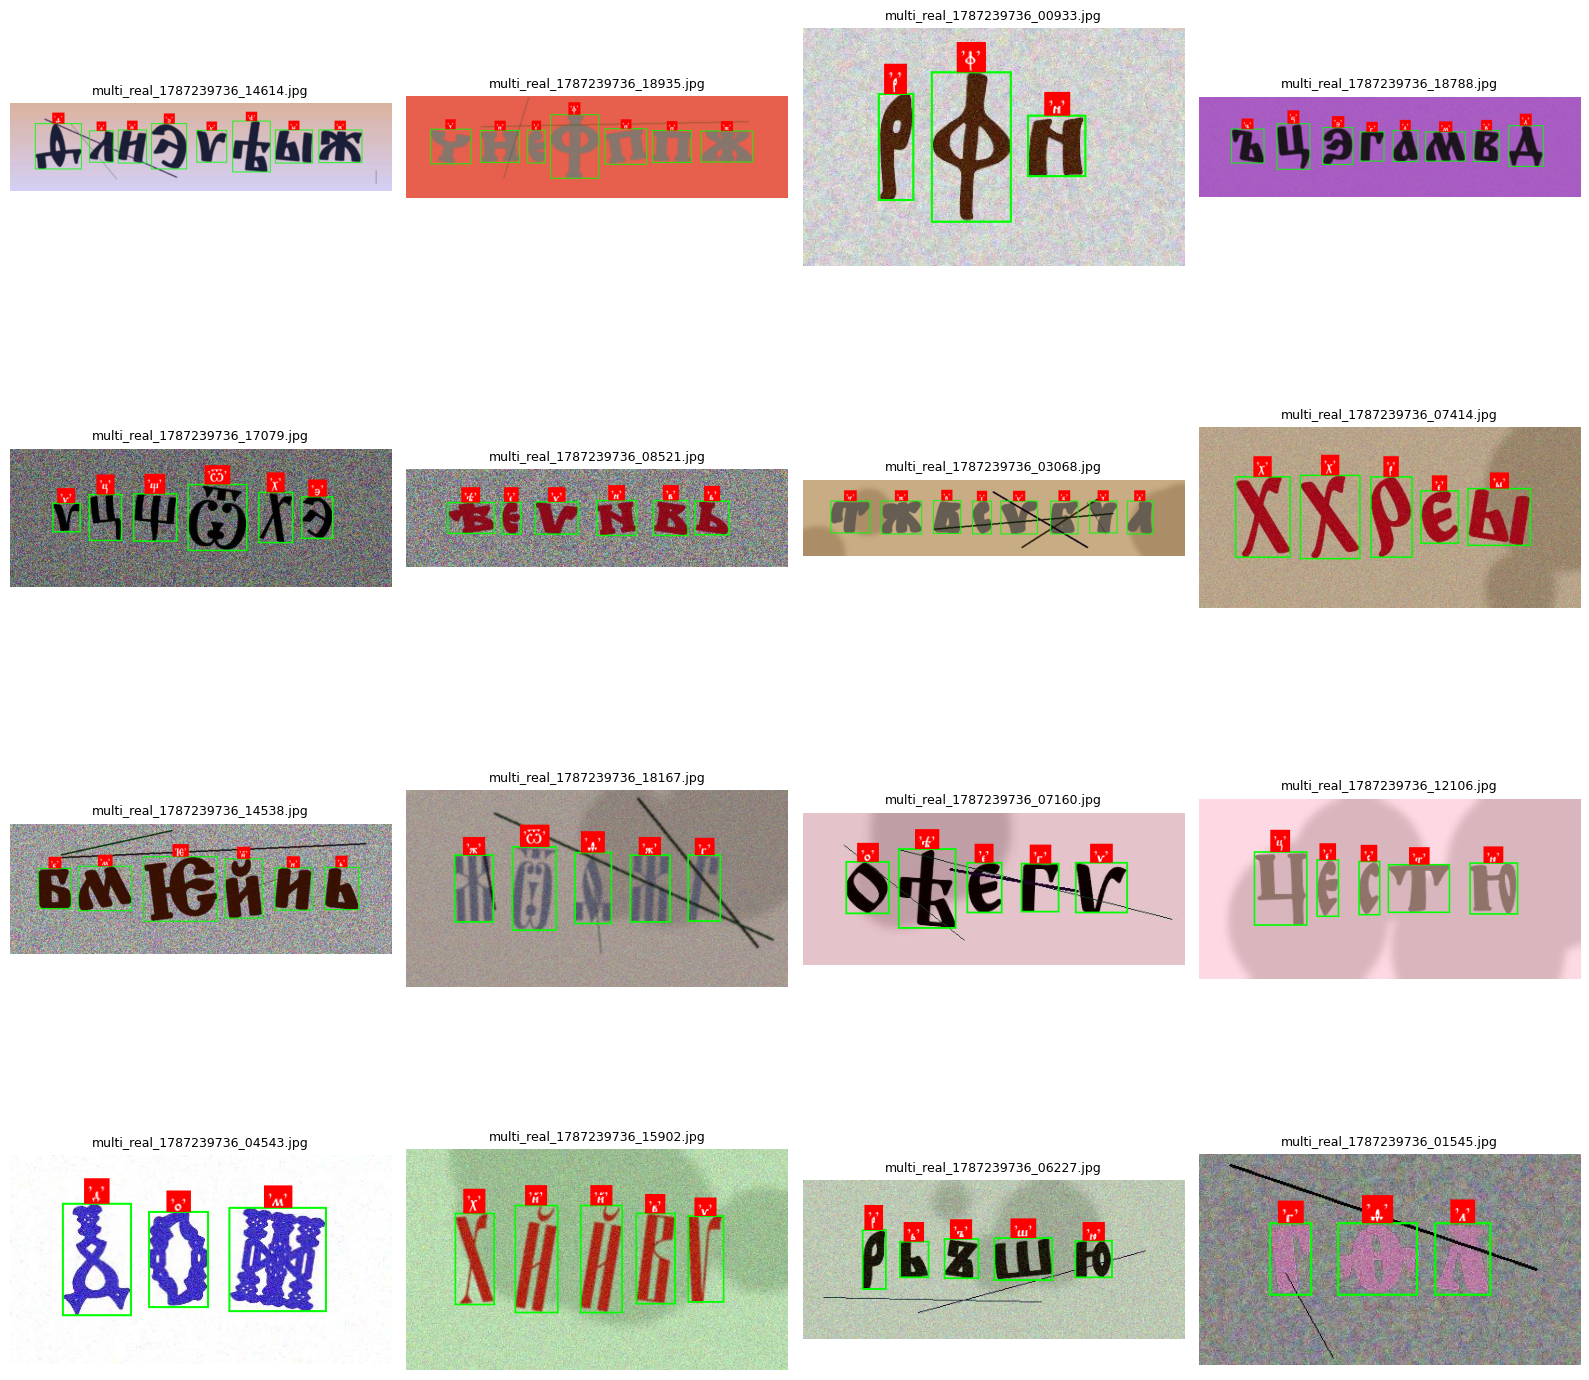

In [9]:
import os
import glob
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

def show_dataset_samples(n_samples=16):
    # جلب مسارات الصور
    train_images = glob.glob(os.path.join(DATASET_ROOT, "train", "images", "*.jpg"))
    val_images   = glob.glob(os.path.join(DATASET_ROOT, "val", "images", "*.jpg"))
    test_images  = glob.glob(os.path.join(DATASET_ROOT, "test", "images", "*.jpg"))

    total_images = len(train_images) + len(val_images) + len(test_images)

    print("📊 إحصائيات Dataset:")
    print(f"  📁 الموقع: {DATASET_ROOT}")
    print(f"  🖼️ إجمالي الصور: {total_images:,}")
    print(f"  🟢 تدريب (Train): {len(train_images):,}")
    print(f"  🟡 اختبار (Val): {len(val_images):,}")
    print(f"  🔴 تقييم (Test): {len(test_images):,}\n")

    if total_images == 0:
        print("⚠️ لم يتم العثور على أي صور في المجلد!")
        return

    # 1. تحميل الخط السلافي/السيريلكي بحجم مناسب وواضح
    font_files = glob.glob(os.path.join(FONTS_DIR, "**", "*.ttf"), recursive=True) + \
                 glob.glob(os.path.join(FONTS_DIR, "**", "*.otf"), recursive=True)

    pil_font = None
    if font_files:
        try:
            # حجم الخط 18 يمنح شكلاً واضحاً ومطابقاً للصورة
            pil_font = ImageFont.truetype(font_files[0], size=18)
        except Exception:
            pil_font = ImageFont.load_default()

    selected_img_paths = random.sample(train_images, min(n_samples, len(train_images)))

    cols = 4
    rows = (len(selected_img_paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten() if isinstance(axes, (list, np.ndarray)) else [axes]

    for idx, img_path in enumerate(selected_img_paths):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        label_path = img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")

        if os.path.exists(label_path):
            with open(label_path, 'r', encoding='utf-8') as f:
                lines = f.readlines()

            pil_img = Image.fromarray(img)
            draw = ImageDraw.Draw(pil_img)

            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id, x_c, y_c, bw, bh = map(float, parts)
                    cls_id = int(cls_id)

                    xmin = max(0, int((x_c - bw / 2) * w))
                    ymin = max(0, int((y_c - bh / 2) * h))
                    xmax = min(w, int((x_c + bw / 2) * w))
                    ymax = min(h, int((y_c + bh / 2) * h))

                    # 1. رسم المربع الأخضر السميك حول الحرف
                    draw.rectangle([xmin, ymin, xmax, ymax], outline=(0, 255, 0), width=2)

                    # 2. اسم الحرف متبوعاً باقتباس مفرد كما في الصورة ('а')
                    cls_name = characters[cls_id] if ('characters' in globals() and cls_id < len(characters)) else str(cls_id)
                    label_text = f"'{cls_name}'"

                    # 3. حساب حجم صندوق النص
                    if pil_font:
                        bbox = draw.textbbox((0, 0), label_text, font=pil_font)
                        text_w = bbox[2] - bbox[0]
                        text_h = bbox[3] - bbox[1]
                    else:
                        text_w, text_h = 20, 14

                    # 4. محاذاة الصندوق الأحمر تماماً فوق منتصف المربع الأخضر
                    box_center_x = (xmin + xmax) // 2
                    bg_xmin = max(0, box_center_x - (text_w + 8) // 2)
                    bg_xmax = min(w, bg_xmin + text_w + 8)

                    if ymin - text_h - 8 > 0:
                        bg_ymin = ymin - text_h - 8
                        bg_ymax = ymin
                    else:
                        bg_ymin = ymin
                        bg_ymax = ymin + text_h + 8

                    # 5. رسم المربع الأحمر وكتابة النص الأبيض بداخله
                    draw.rectangle([bg_xmin, bg_ymin, bg_xmax, bg_ymax], fill=(255, 0, 0))
                    draw.text((bg_xmin + 4, bg_ymin + 1), label_text, fill=(255, 255, 255), font=pil_font)

            img = np.array(pil_img)

        axes[idx].imshow(img)
        axes[idx].set_title(os.path.basename(img_path), fontsize=9)
        axes[idx].axis('off')

    for i in range(len(selected_img_paths), len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# تشغيل المعاينة
show_dataset_samples(16)

In [13]:
import shutil
import os

# إنشاء المجلد في RAM Disk ونسخ البيانات إليه
src = "/content/drive/MyDrive/Old_Russian/Dataset_YOLO"
dst = "/dev/shm/Dataset_YOLO"

if os.path.exists(src):
    shutil.copytree(src, dst, dirs_exist_ok=True)
    print("✅ تم نسخ البيانات بنجاح إلى RAM Disk!")
else:
    print("❌ لم يتم العثور على المجلد المصدر في Google Drive!")

✅ تم نسخ البيانات بنجاح إلى RAM Disk!


In [ ]:
pip install ultralytics

In [12]:
import json
import yaml
import os
from ultralytics import YOLO

# 1. تحديد المسارات الدقيقة بناءً على هيكل المجلدات لديك
BASE_DIR = "/content/drive/MyDrive/Old_Russian"
DATASET_ROOT = os.path.join(BASE_DIR, "Dataset_YOLO")
JSON_PATH = os.path.join(BASE_DIR, "Alphabet.json")

# 2. قراءة الحروف من ملف Alphabet.json
with open(JSON_PATH, 'r', encoding='utf-8') as f:
    alphabet_data = json.load(f)

# استخراج قائمة الحروف سواء كانت List أو Dict
if isinstance(alphabet_data, dict):
    first_val = list(alphabet_data.values())[0]
    characters = first_val if isinstance(first_val, list) else list(alphabet_data.keys())
else:
    characters = alphabet_data

# 3. إعداد محتوى ملف data.yaml
data_yaml_content = {
    'path': DATASET_ROOT,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': len(characters),
    'names': characters
}

# 4. حفظ ملف data.yaml داخل مجلد Dataset_YOLO
yaml_path = os.path.join(DATASET_ROOT, "data.yaml")
with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(data_yaml_content, f, allow_unicode=True, sort_keys=False)

print(f"✅ تم إنشاء ملف data.yaml بنجاح في: {yaml_path}")
print(f"📊 عدد الفئات (Classes): {len(characters)}")


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ تم إنشاء ملف data.yaml بنجاح في: /content/drive/MyDrive/Old_Russian/Dataset_YOLO/data.yaml
📊 عدد الفئات (Classes): 38


In [14]:

from ultralytics import YOLO
import torch
import os
import time

# ============================================
# إعدادات المسارات والتدريب
# ============================================
DATASET_ROOT = "/dev/shm/Dataset_YOLO"
MODEL_SAVE_DIR = "/content/drive/MyDrive/Old_Russian/Models"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

MAX_EPOCHS = 100
PATIENCE = 15
BATCH_SIZE = 32
IMG_SIZE = 384
LEARNING_RATE = 0.01
NUM_DATALOADER_WORKERS = 8
GLOBAL_SEED = 42
DEVICE = 0

def monitor_gpu():
    if not torch.cuda.is_available(): return
    gpu_mem_total = torch.cuda.get_device_properties(0).total_memory / (1024**2)
    gpu_mem_allocated = torch.cuda.memory_allocated(0) / (1024**2)
    print(f"📊 GPU Memory: {gpu_mem_allocated:.0f}/{gpu_mem_total:.0f} MB ({gpu_mem_allocated/gpu_mem_total*100:.1f}%)")

def train_yolo_gpu():
    yaml_file = os.path.join(DATASET_ROOT, "data.yaml")
    if not os.path.exists(yaml_file):
        print(f"❌ خطأ: ملف data.yaml غير موجود في المسار: {yaml_file}")
        return None

    last_model_file = os.path.join(MODEL_SAVE_DIR, "ocr_training", "weights", "last.pt")

    if os.path.exists(last_model_file):
        print(f"🔄 استكمال التدريب من آخر نقطة حفظ: {last_model_file}")
        model = YOLO(last_model_file)
        resume_training = True
    else:
        print("🚀 بدء تدريب نموذج جديد من البداية...")
        model = YOLO('yolov8n.pt')
        resume_training = False

    print(f"🚀 بدء التدريب على GPU | البيانات: {DATASET_ROOT}")
    total_start = time.time()

    try:
        results = model.train(
            data=yaml_file,
            epochs=MAX_EPOCHS,
            batch=BATCH_SIZE,
            imgsz=IMG_SIZE,
            lr0=LEARNING_RATE,
            patience=PATIENCE,
            workers=NUM_DATALOADER_WORKERS,
            device=DEVICE,
            amp=True,
            cache=True,
            save=True,
            save_period=1,
            project=MODEL_SAVE_DIR,
            name="ocr_training",
            exist_ok=True,
            seed=GLOBAL_SEED,
            deterministic=True,
            resume=resume_training,
            half=True
        )

        monitor_gpu()

    except Exception as e:
        print(f"❌ خطأ أثناء التدريب: {e}")
        return None

    print(f"✅ اكتمل التدريب. الوقت الكلي: {(time.time() - total_start)/60:.1f} دقيقة")
    return model

# تشغيل التدريب
trained_model = train_yolo_gpu()

🚀 بدء تدريب نموذج جديد من البداية...
🚀 بدء التدريب على GPU | البيانات: /dev/shm/Dataset_YOLO
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.124 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/dev/shm/Dataset_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=384, iou=0.7, keras=False, kobj=1.0, l

In [ ]:

# ============================================================================
# CELL 7 (الكود الكامل والمعدل نهائياً مع سحب القاموس من النموذج مباشرة) — واجهة Gradio
# ============================================================================

import os
import traceback
import numpy as np
import gradio as gr
from pathlib import Path
from PIL import Image, ImageDraw
from ultralytics import YOLO

# تحديد مسار النموذج النهائي مباشرة
FINAL_MODEL = Path("/content/drive/MyDrive/Old_Russian/Models/ocr_training/weights/best.pt")

def load_inference_model():
    model_path = str(FINAL_MODEL)
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"لم يتم العثور على ملف النموذج في المسار: {model_path}")
    return YOLO(model_path)

# تحميل النموذج أولاً وسحب قاموس الحروف (ID_TO_CHAR) مباشرة منه لضمان تطابق تام ومطلق
ID_TO_CHAR = {}
try:
    temp_model = load_inference_model()
    ID_TO_CHAR = temp_model.names  # YOLO يخزن أسماء الفئات بالترتيب الصحيح بداخله
    print(f"✅ تم تحميل قاموس الحروف بنجاح مباشرة من النموذج المدرب! (عدد الحروف: {len(ID_TO_CHAR)})")
except Exception as e:
    print(f"⚠️ حدث خطأ أثناء سحب القاموس من النموذج: {e}")


def group_boxes_into_text(boxes_xyxy, cls_ids, line_thresh_ratio=0.6, space_factor=0.5):
    if len(boxes_xyxy) == 0:
        return ""

    heights = boxes_xyxy[:, 3] - boxes_xyxy[:, 1]
    median_h = np.median(heights) if len(heights) else 20
    y_centers = (boxes_xyxy[:, 1] + boxes_xyxy[:, 3]) / 2
    order = np.argsort(y_centers)

    lines = []
    current = [order[0]]
    current_y = y_centers[order[0]]

    for idx in order[1:]:
        if abs(y_centers[idx] - current_y) <= median_h * line_thresh_ratio:
            current.append(idx)
        else:
            lines.append(current)
            current = [idx]
            current_y = y_centers[idx]
    lines.append(current)

    output = []
    for line in lines:
        # ترتيب حروف السطر الواحد أفقياً من اليسار إلى اليمين
        line = sorted(line, key=lambda i: boxes_xyxy[i][0])

        line_chars = []
        widths = [boxes_xyxy[i][2] - boxes_xyxy[i][0] for i in line]
        avg_w = np.mean(widths) if widths else 15

        for i, idx in enumerate(line):
            # إذا وُجدت فجوة أفقية أكبر من المعتاد بين حرف والذي يليه، يتم إدراج مسافة (Space)
            if i > 0:
                prev_x2 = boxes_xyxy[line[i-1]][2]
                curr_x1 = boxes_xyxy[idx][0]
                gap = curr_x1 - prev_x2
                if gap > (avg_w * space_factor):
                    line_chars.append(" ")

            char = ID_TO_CHAR.get(int(cls_ids[idx]), "?")
            line_chars.append(char)

        output.append("".join(line_chars))

    return "\n".join(output)


def draw_bboxes(image, boxes_xyxy, cls_ids, confs):
    image = image.convert("RGB").copy()
    draw = ImageDraw.Draw(image)
    for box, cid, conf in zip(boxes_xyxy, cls_ids, confs):
        x1, y1, x2, y2 = map(int, box)
        draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
        label = f"{ID_TO_CHAR.get(int(cid), '?')} ({conf:.2f})"
        draw.text((x1, max(0, y1 - 15)), label, fill="blue")
    return image


_INFERENCE_MODEL = None


def process_image(image, conf_thresh, line_ratio):
    global _INFERENCE_MODEL
    try:
        if image is None:
            return None, "الرجاء رفع صورة أولاً."

        if _INFERENCE_MODEL is None:
            _INFERENCE_MODEL = load_inference_model()

        results = _INFERENCE_MODEL.predict(source=image, conf=conf_thresh, verbose=False)

        if len(results) == 0 or results[0].boxes is None or len(results[0].boxes) == 0:
            return image, "لم يتم العثور على أي حروف مطابقة."

        boxes = results[0].boxes.xyxy.cpu().numpy()
        cls_ids = results[0].boxes.cls.cpu().numpy()
        confs = results[0].boxes.conf.cpu().numpy()

        annotated = draw_bboxes(image, boxes, cls_ids, confs)
        text = group_boxes_into_text(boxes, cls_ids, line_thresh_ratio=line_ratio)

        return annotated, text

    except Exception:
        err = traceback.format_exc()
        print(err)
        return image, err


# تصميم واجهة Gradio
with gr.Blocks(title="OCR — السلافية الكنسية القديمة") as demo:
    gr.Markdown("# 📜 نظام التعرف البصري على الحروف (OCR) - السلافية الكنسية القديمة")
    gr.Markdown("قم برفع صورة المخطوط أو الأثر، واضبط إعدادات الكشف ثم اضغط على **استخراج النص**.")

    with gr.Row():
        with gr.Column(scale=1):
            img_in = gr.Image(type="pil", label="ارفع صورة الأثر أو المخطوط")

            with gr.Accordion("إعدادات متقدمة", open=False):
                conf_slider = gr.Slider(minimum=0.1, maximum=0.9, value=0.15, step=0.05, label="عتبة الثقة (Confidence Threshold)")
                line_slider = gr.Slider(minimum=0.2, maximum=1.5, value=0.6, step=0.1, label="حساسية تجميع الأسطر (Line Spacing Ratio)")

            btn = gr.Button("🔍 استخراج النص وتحديد الحروف", variant="primary")

        with gr.Column(scale=1):
            img_out = gr.Image(label="الصورة مع مربعات التحديد (Bounding Boxes)")
            txt_out = gr.Textbox(label="النص المستخرج", lines=10, max_lines=20)

    btn.click(
        fn=process_image,
        inputs=[img_in, conf_slider, line_slider],
        outputs=[img_out, txt_out]
    )

demo.queue()
demo.launch(share=True, debug=True)


✅ تم تحميل قاموس الحروف بنجاح مباشرة من النموذج المدرب! (عدد الحروف: 38)
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://5726d2f8b925e9a034.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [11]:
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO

# تصحيح المسار مباشرة ليتطابق مع مجلد Dataset_YOLO الموجود في /dev/shm
DATASET_ROOT = "/dev/shm/Dataset_YOLO"
MODEL_SAVE_DIR = "/content/drive/MyDrive/Old_Russian/Models"

def evaluate_model(model_path=None):
    """تقييم الموديل مع تصحيح المسارات"""
    global model
    if 'model' not in globals() or model is None:
        if model_path and os.path.exists(model_path):
            print(f"📥 تحميل النموذج من: {model_path}")
            model = YOLO(model_path)
        else:
            print("❌ خطأ: لم يتم العثور على النموذج.")
            return None

    test_images_dir = os.path.join(DATASET_ROOT, "test", "images")
    test_labels_dir = os.path.join(DATASET_ROOT, "test", "labels")

    print(f"🔍 البحث عن صور الاختبار في: {test_images_dir}")
    print(f"🔍 البحث عن ملفات التسمية في: {test_labels_dir}")

    # فحص المسارات
    if not os.path.exists(test_labels_dir):
        print(f"❌ الخطأ: المجلد غير موجود: {test_labels_dir}")
        return None

    y_true = []
    y_pred = []

    print("🚀 بدء التقييم...")

    for label_file in tqdm(os.listdir(test_labels_dir), desc="تقييم"):
        if not label_file.endswith('.txt'):
            continue

        label_path = os.path.join(test_labels_dir, label_file)
        with open(label_path, 'r') as f:
            line = f.readline()
            if not line:
                continue
            true_class = int(line.split()[0])

        img_file = label_file.replace('.txt', '.jpg')
        img_path = os.path.join(test_images_dir, img_file)

        if os.path.exists(img_path):
            results = model.predict(img_path, conf=0.5, verbose=False)
            result = results[0]

            if result.boxes is not None and len(result.boxes) > 0:
                pred_class = int(result.boxes.cls[0].cpu().numpy())
                y_pred.append(pred_class)
            else:
                y_pred.append(-1)

            y_true.append(true_class)

    if len(y_true) == 0:
        print("❌ تحذير: لم يتم العثور على أي بيانات مطابقة للتقييم!")
        return 0

    correct = sum(1 for t, p in zip(y_true, y_pred) if t == p)
    accuracy = correct / len(y_true) * 100

    print(f"\n📊 النتائج النهائية:")
    print(f"  ✅ Accuracy: {accuracy:.2f}%")
    print(f"  📈 Correct: {correct}/{len(y_true)}")

    return accuracy

# تنفيذ التقييم باستخدام أفضل نموذج مدرب
best_model_path = os.path.join(MODEL_SAVE_DIR, "ocr_training", "weights", "best.pt")
accuracy = evaluate_model(model_path=best_model_path)

🔍 البحث عن صور الاختبار في: /dev/shm/Dataset_YOLO/test/images
🔍 البحث عن ملفات التسمية في: /dev/shm/Dataset_YOLO/test/labels
🚀 بدء التقييم...


تقييم: 100%|██████████| 1900/1900 [00:25<00:00, 73.71it/s] 


📊 النتائج النهائية:
  ✅ Accuracy: 25.58%
  📈 Correct: 486/1900
